<a href="https://colab.research.google.com/github/Adhi1755/Multi-Country-GDP-Forecasting/blob/main/AI_Based_Multi_Country_GDP_Forecasting_using_LSTM%2C_VAR%2C_and_Economic_Indicators.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [89]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# AI-Based Multi-Country GDP Forecasting using LSTM, VAR, and Economic Indicators

## Project Overview

This notebook presents an end-to-end machine learning and deep learning project focused on forecasting Gross Domestic Product (GDP) for multiple countries using various economic indicators. The project involves data collection, comprehensive cleaning and preprocessing, exploratory data analysis (EDA), feature engineering, and the implementation of two distinct time series forecasting models: a Vector Autoregression (VAR) model and a Long Short-Term Memory (LSTM) neural network. The performance of these models is evaluated and compared to provide insights into their suitability for multi-country economic forecasting.

## Problem Statement

Accurate GDP forecasting is crucial for economic policy-making, investment decisions, and business strategy. Traditional economic models often struggle with the complex, non-linear relationships and interdependencies across multiple economic indicators and countries. This project aims to develop robust forecasting models that can predict GDP for a diverse set of countries, leveraging historical economic data to capture intricate patterns and improve prediction accuracy. The challenge involves effectively handling missing data, identifying relevant features, and comparing different modeling approaches (traditional statistical vs. deep learning) to determine the most effective strategy for this multi-country forecasting task.

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from statsmodels.tsa.api import VAR
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import os # Import os module for file operations

# Mount Google Drive to access data files
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Dataset Description

The dataset consists of various economic indicators collected annually for a selection of countries over several decades. Each country's data is stored in a separate CSV file. The key economic indicators included are:

*   `countrycode`: ISO country code.
*   `country`: Name of the country.
*   `currency_unit`: Currency used by the country.
*   `year`: Year of observation.
*   `GDP`: Gross Domestic Product (annual growth rate, percent).
*   `net population growth`: Annual net population growth rate.
*   `CPI`: Consumer Price Index (annual growth rate).
*   `employment rate`: Annual employment rate (percentage of total labor force).
*   `labsh`: Labor share of income.
*   `xr`: Exchange rate.
*   `pl_gdpo`, `csh_c`, `csh_i`, `csh_g`, `csh_x`, `csh_m`, `csh_r`, `pl_c`, `pl_i`, `pl_g`, `pl_x`, `pl_m`, `pl_n`, `pl_k`: Additional economic variables representing various price levels, consumption shares, investment shares, and capital shares.

The goal is to forecast GDP using a subset of these features, which represent a mix of macroeconomic and demographic factors.

## Data Collection and Merging

This section handles the loading of individual country CSV files from a specified Google Drive folder and merges them into a single pandas DataFrame. This consolidated DataFrame forms the basis for all subsequent data processing and modeling steps.

In [92]:
folder_path = "/content/drive/MyDrive/Google Colab/GDP"  # Define the path to your data folder

all_data = []

# Iterate through each file in the specified folder
for file in os.listdir(folder_path):
    # Process only CSV files
    if file.endswith(".csv"):
        file_path = os.path.join(folder_path, file)

        # Read each CSV file into a DataFrame
        df = pd.read_csv(file_path)

        # Append the DataFrame to the list
        all_data.append(df)

# Combine all individual DataFrames into a single DataFrame
final_df = pd.concat(all_data, ignore_index=True)

# Save the combined dataset to a new CSV file for future use
final_df.to_csv("combined_data.csv", index=False)

print(f"Shape of combined DataFrame: {final_df.shape}")
print("First 5 rows of the combined DataFrame:")
display(final_df.head())

Shape of combined DataFrame: (484, 25)
First 5 rows of the combined DataFrame:


,countrycode,country,currency_unit,year,GDP,net population growth,CPI,employment rate,labsh,xr,...,csh_m,csh_r,pl_c,pl_i,pl_g,pl_x,pl_m,pl_n,pl_k,GDP.1
0,IND,India,Indian Rupee,1979.0,NaN,682.995354,NaN,256.839111,0.709059,8.125791,...,-0.027104,-0.063782,0.190954,0.224667,0.074652,0.292258,0.374884,0.140270,0.623519,NaN
1,IND,India,Indian Rupee,1980.0,5.281,0.023364,11.34606,0.007102,0.038942,-0.032347,...,0.311639,-0.235969,0.221119,0.115094,0.211470,0.029731,0.119947,0.198038,0.040884,5.281
2,IND,India,Indian Rupee,1981.0,6.006,0.023510,13.11255,0.004508,-0.027032,0.101181,...,0.171218,-0.391245,0.024342,0.200461,0.124758,0.062000,-0.101080,0.141719,0.044442,6.006
3,IND,India,Indian Rupee,1982.0,3.476,0.023560,7.89075,0.004125,-0.013325,0.092003,...,-0.227116,0.640088,0.022520,0.062986,0.090714,0.009650,-0.020343,0.142196,0.070686,3.476
4,IND,India,Indian Rupee,1983.0,7.289,0.023475,11.86807,0.003785,0.016143,0.068086,...,0.568956,-0.435581,0.036162,0.053462,0.145769,0.073353,-0.117499,0.109214,-0.044686,7.289


## Data Cleaning and Preprocessing

This section focuses on cleaning the raw, merged dataset to ensure data quality and prepare it for analysis. Steps include removing duplicates, handling missing values through interpolation and forward/backward fill, dropping irrelevant columns, and standardizing categorical data.

In [93]:
# Remove any duplicate rows that might exist in the dataset
final_df = final_df.drop_duplicates()

# Sort the DataFrame by country and year to prepare for time series operations
final_df = final_df.sort_values(by=["country", "year"])

# Reset the index of the DataFrame after sorting and dropping duplicates
final_df = final_df.reset_index(drop=True)

print("First 10 rows after removing duplicates and sorting:")
display(final_df.head(10))

First 10 rows after removing duplicates and sorting:


,countrycode,country,currency_unit,year,GDP,net population growth,CPI,employment rate,labsh,xr,...,csh_m,csh_r,pl_c,pl_i,pl_g,pl_x,pl_m,pl_n,pl_k,GDP.1
0,AUS,Australia,Australian Dollar,1979.0,NaN,NaN,NaN,0.424046,0.671457,0.894641,...,-0.133266,-0.020685,0.413889,0.413534,0.596601,0.336825,0.352681,0.367371,0.847923,NaN
1,AUS,Australia,Australian Dollar,1980.0,2.716400,0.012170,10.135840,0.014768,0.001261,0.878244,...,0.141475,0.874780,0.109504,0.089383,0.134099,0.056886,0.028617,0.136190,0.092870,2.716400
2,AUS,Australia,Australian Dollar,1981.0,4.181536,0.012944,9.487666,-0.000382,0.007703,0.870215,...,0.076584,-0.183342,0.104287,0.113863,0.125933,0.055314,0.051605,0.133049,-0.036368,4.181536
3,AUS,Australia,Australian Dollar,1982.0,-0.364700,0.013668,11.351820,-0.015984,-0.002571,0.985863,...,0.028271,-0.362804,-0.024338,-0.056759,-0.026207,-0.013163,0.000060,-0.020829,-0.090090,-0.364700
4,AUS,Australia,Australian Dollar,1983.0,-0.184830,0.014382,10.038910,-0.029561,-0.044002,1.110015,...,-0.182838,0.171457,-0.051031,-0.042226,-0.050459,-0.072424,-0.068044,-0.047157,-0.018731,-0.184830
5,AUS,Australia,Australian Dollar,1984.0,6.576746,0.015040,3.960396,0.01945,-0.002186,1.139519,...,0.067292,0.040609,0.035117,0.042548,0.043212,0.045620,0.073493,0.040041,-0.042871,6.576746
6,AUS,Australia,Australian Dollar,1985.0,5.055644,0.015593,6.734694,0.018711,-0.004355,1.431895,...,0.011098,0.507724,-0.147210,-0.144076,-0.157623,-0.060706,-0.028623,-0.115613,-0.180308,5.055644
7,AUS,Australia,Australian Dollar,1986.0,1.820488,0.016210,9.050350,0.027526,-0.015342,1.495974,...,-0.104579,-0.414397,0.035560,0.047459,-0.018288,0.107778,0.154201,0.049556,0.058110,1.820488
8,AUS,Australia,Australian Dollar,1987.0,5.297433,0.016686,8.533022,0.006751,-0.029674,1.428180,...,-0.088516,-0.405617,0.121223,0.094584,0.062825,0.086042,0.117389,0.102248,0.235196,5.297433
9,AUS,Australia,Australian Dollar,1988.0,4.442069,0.016628,7.215940,0.020948,-0.006701,1.279908,...,0.138284,-0.022463,0.185243,0.193945,0.157989,0.112380,0.017341,0.192385,0.193642,4.442069


In [94]:
# Display unique countries to check for consistency and potential errors
print("Unique countries in the dataset:")
print(final_df['country'].unique())

# Check for missing values in each column
print("\nMissing values before detailed handling:")
print(final_df.isnull().sum())

Unique countries in the dataset:
['Australia' 'Brazil' 'Canada' 'China' 'France' 'Germany' 'India' 'Italy'
 'Japan' 'Russian Federation' 'South Africa' 'United States' nan]

Missing values before detailed handling:
countrycode               3
country                   3
currency_unit             3
year                      3
GDP                      12
net population growth     4
CPI                      11
employment rate           1
labsh                     3
xr                        3
pl_gdpo                   3
csh_c                     3
csh_i                     3
csh_g                     3
csh_x                     3
csh_m                     3
csh_r                     3
pl_c                      3
pl_i                      3
pl_g                      3
pl_x                      3
pl_m                      3
pl_n                      3
pl_k                      4
GDP.1                    13
dtype: int64


In [95]:
# Drop rows where the 'country' column is null, as these entries are unidentifiable
final_df = final_df.dropna(subset=['country'])

# The 'GDP.1' column appears to be a duplicate or an artifact, so it's removed
final_df = final_df.drop(columns=['GDP.1'])

In [96]:
# Interpolate missing values within each country's time series data.
# This fills NaNs based on existing values for that specific country.
final_df = final_df.groupby('country').apply(lambda group: group.interpolate(method='linear')).reset_index(drop=True)

# Fill any remaining NaNs (e.g., at the start/end of a series) using forward-fill then backward-fill.
# This ensures no missing values are left that interpolation couldn't handle.
final_df = final_df.fillna(method='ffill').fillna(method='bfill')

/tmp/ipykernel_2999/2830738451.py:3: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  final_df = final_df.groupby('country').apply(lambda group: group.interpolate(method='linear')).reset_index(drop=True)
/tmp/ipykernel_2999/2830738451.py:3: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  final_df = final_df.groupby('country').apply(lambda group: group.interpolate(method='linear')).reset_index(drop=True)
/tmp/ipykernel_2999/2830738451.py:3: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  final_df = final_df.groupby('country').apply(lambda group: group.interpolate(method='linear')).reset_index(drop=True)
/tmp/ipykernel_2999

In [97]:
# Verify that all missing values have been handled
print("Missing values after interpolation and fillna:")
print(final_df.isnull().sum())

Missing values after interpolation and fillna:
countrycode              0
country                  0
currency_unit            0
year                     0
GDP                      0
net population growth    0
CPI                      0
employment rate          0
labsh                    0
xr                       0
pl_gdpo                  0
csh_c                    0
csh_i                    0
csh_g                    0
csh_x                    0
csh_m                    0
csh_r                    0
pl_c                     0
pl_i                     0
pl_g                     0
pl_x                     0
pl_m                     0
pl_n                     0
pl_k                     0
dtype: int64


In [98]:
# Standardize country names for consistency, e.g., 'Russian Federation' to 'Russia'
final_df['country'] = final_df['country'].replace({
    'Russian Federation': 'Russia'
})

print(f"Shape of final DataFrame after cleaning: {final_df.shape}")

Shape of final DataFrame after cleaning: (481, 24)


## Exploratory Data Analysis (EDA)

This section performs exploratory data analysis to understand the distributions of key variables, identify trends, and discover relationships within the data. Visualizations are used to highlight patterns and potential outliers.

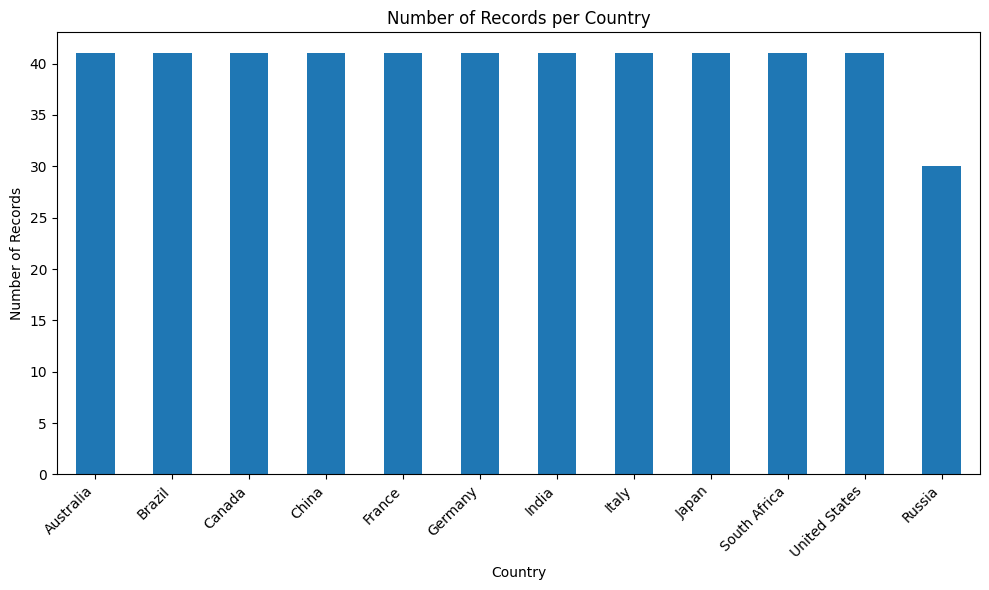

In [99]:
# Visualize the number of records per country
plt.figure(figsize=(10, 6))
final_df['country'].value_counts().plot(kind='bar')
plt.title("Number of Records per Country")
plt.xlabel("Country")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

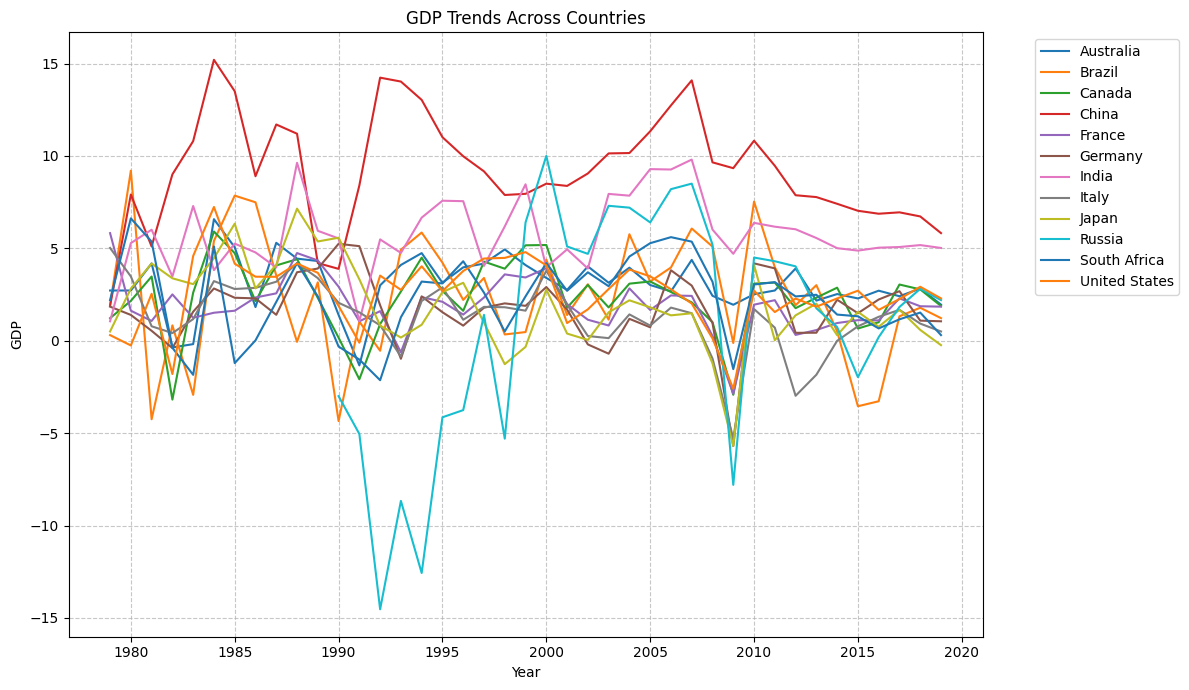

In [100]:
# Plot GDP trends for all countries on a single graph
plt.figure(figsize=(12, 7))
for country in final_df['country'].unique():
    subset = final_df[final_df['country'] == country]
    plt.plot(subset['year'], subset['GDP'], label=country)

plt.title("GDP Trends Across Countries")
plt.xlabel("Year")
plt.ylabel("GDP")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

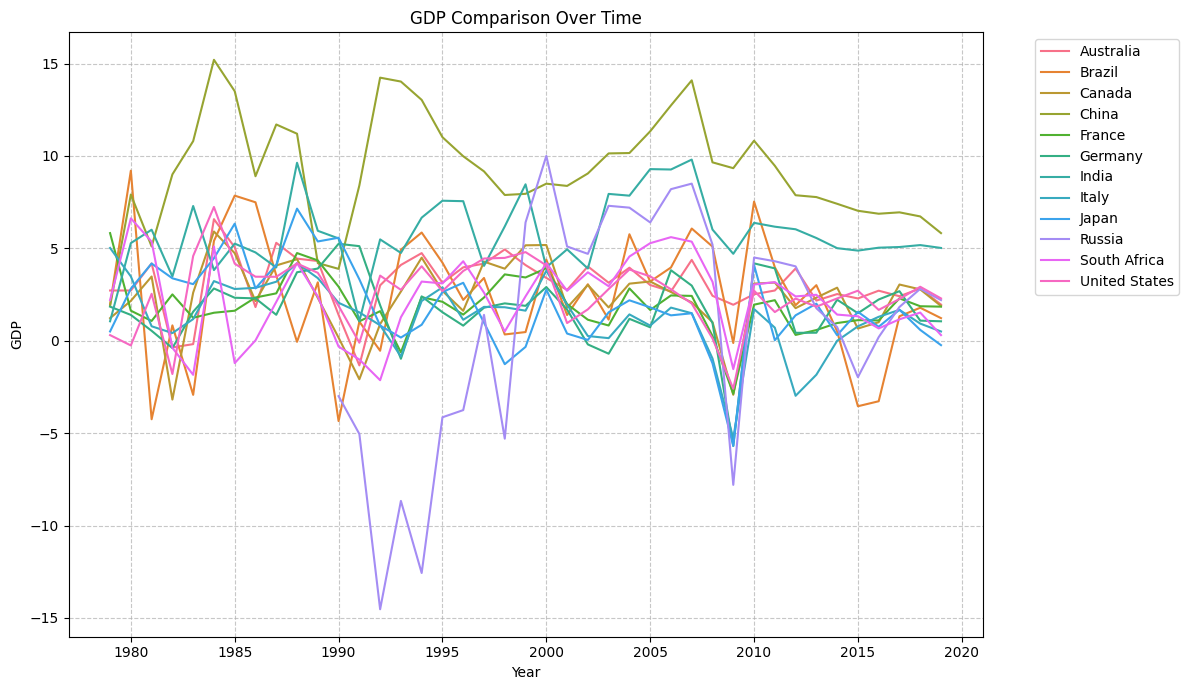

In [101]:
# Use seaborn for a more refined GDP comparison line plot
plt.figure(figsize=(12, 7))
sns.lineplot(data=final_df, x='year', y='GDP', hue='country')
plt.title("GDP Comparison Over Time")
plt.xlabel("Year")
plt.ylabel("GDP")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

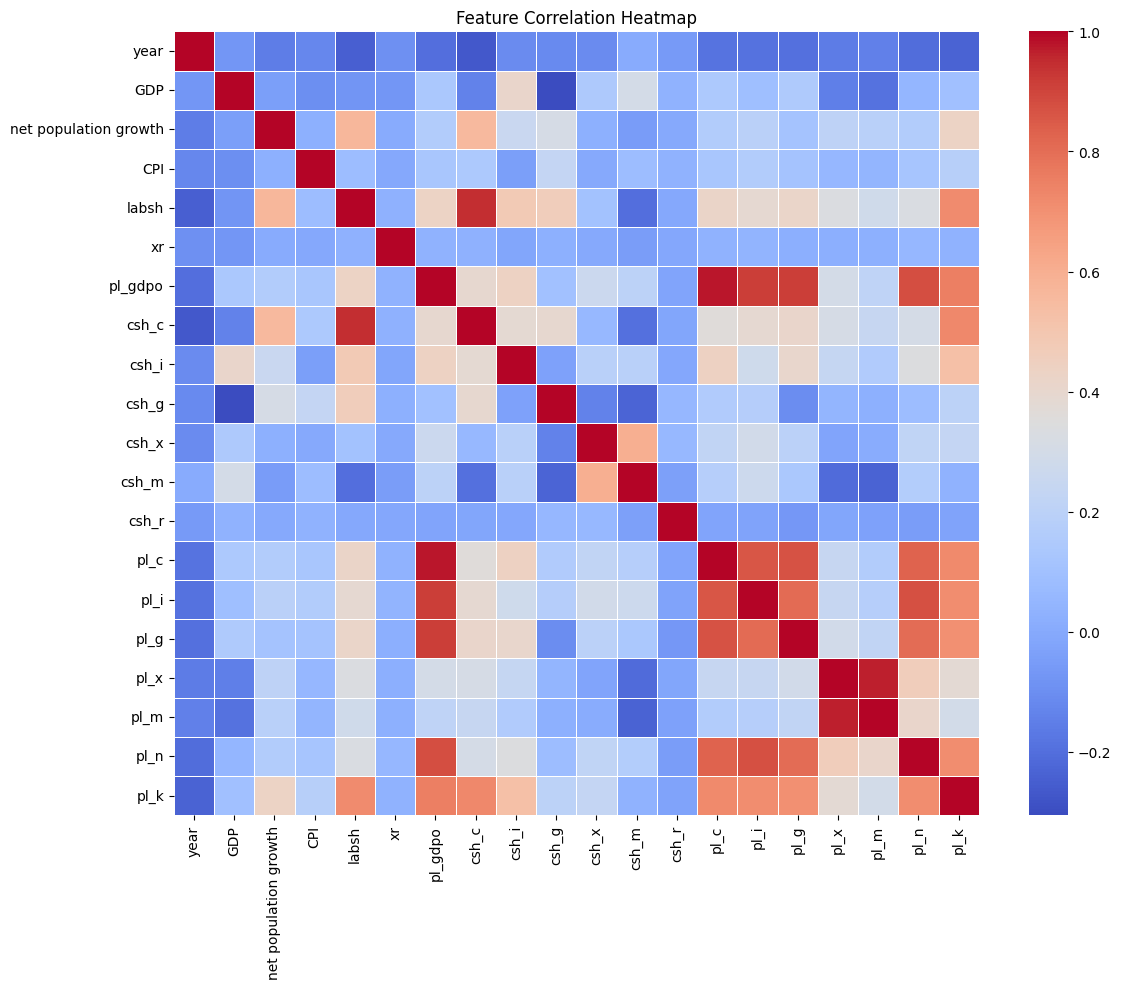

In [102]:
# Calculate and visualize the correlation matrix for numerical features
corr = final_df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

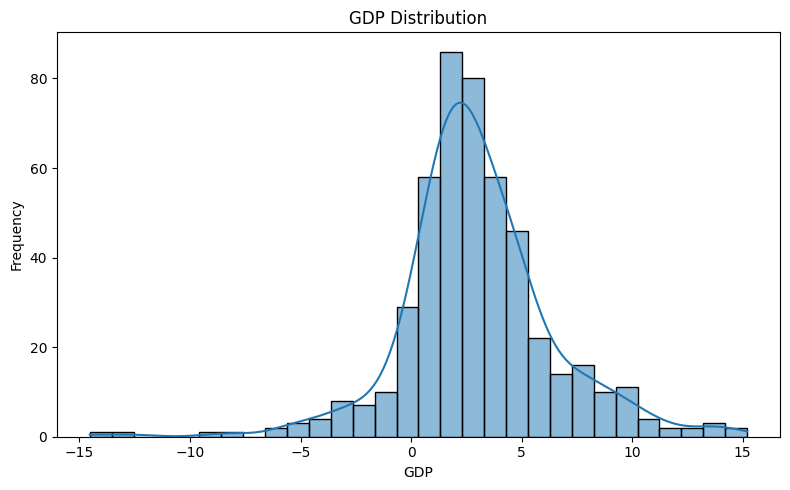

In [103]:
# Visualize the distribution of GDP
plt.figure(figsize=(8, 5))
sns.histplot(final_df['GDP'], kde=True, bins=30)
plt.title("GDP Distribution")
plt.xlabel("GDP")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

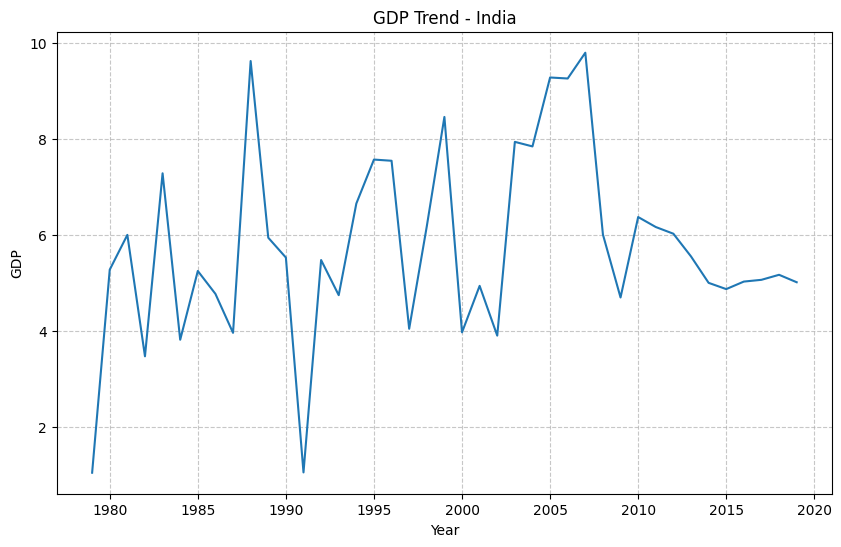

In [104]:
# Example: Plot GDP trend for a specific country (e.g., India)
country_to_plot = "India"
subset = final_df[final_df['country'] == country_to_plot]

plt.figure(figsize=(10, 6))
plt.plot(subset['year'], subset['GDP'])
plt.title(f"GDP Trend - {country_to_plot}")
plt.xlabel("Year")
plt.ylabel("GDP")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

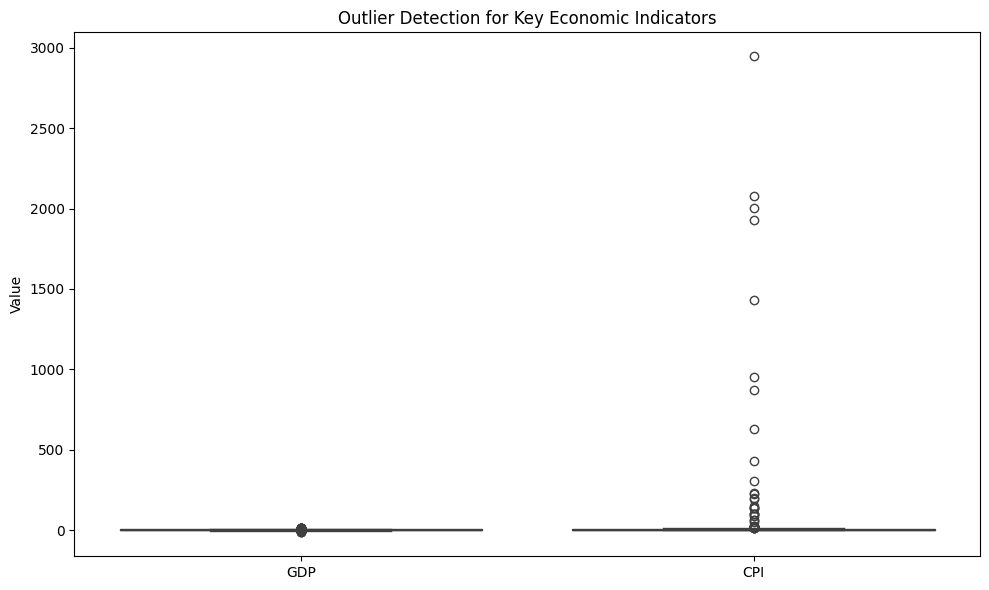

In [105]:
# Use box plots to visualize potential outliers in key economic indicators
plt.figure(figsize=(10, 6))
sns.boxplot(data=final_df[['GDP', 'CPI', 'employment rate']])
plt.title("Outlier Detection for Key Economic Indicators")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

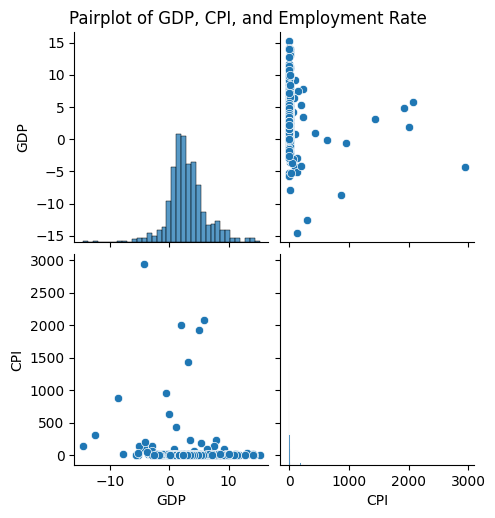

In [106]:
# Create a pairplot to visualize relationships between GDP, CPI, and employment rate
sns.pairplot(final_df[['GDP', 'CPI', 'employment rate']])
plt.suptitle("Pairplot of GDP, CPI, and Employment Rate", y=1.02) # Adjust title position
plt.show()

## Feature Engineering

In this section, a new feature, `GDP_rolling`, is engineered. This feature represents the 3-year rolling mean of GDP, which can help smooth out short-term fluctuations and highlight underlying trends, potentially improving model performance.

In [107]:
# Calculate the 3-year rolling mean of GDP for each country
# This creates a smoothed version of GDP, useful for capturing trends.
final_df['GDP_rolling'] = final_df.groupby('country')['GDP'].rolling(3).mean().reset_index(0, drop=True)

print("First 5 rows with the new 'GDP_rolling' feature:")
display(final_df[['country', 'year', 'GDP', 'GDP_rolling']].head())

First 5 rows with the new 'GDP_rolling' feature:


,country,year,GDP,GDP_rolling
0,Australia,1979.0,2.716400,NaN
1,Australia,1980.0,2.716400,NaN
2,Australia,1981.0,4.181536,3.204779
3,Australia,1982.0,-0.364700,2.177745
4,Australia,1983.0,-0.184830,1.210669


## Data Preparation for Models

This section prepares the data for both the VAR and LSTM models. It involves selecting the relevant features, scaling the data (for LSTM), and splitting the dataset into training and testing sets in a country-wise manner to ensure realistic evaluation of forecasting performance.

In [108]:
# Define the features that will be used for modeling
features = [
    'GDP',
    'CPI',
    'employment rate',
    'net population growth',
    'xr' # Exchange rate
]

# Create a DataFrame containing only the selected features, along with country and year
data = final_df[['country', 'year'] + features].copy()

print("Selected features for modeling:")
display(data.head())

Selected features for modeling:


,country,year,GDP,CPI,employment rate,net population growth,xr
0,Australia,1979.0,2.716400,10.135840,0.424046,0.012170,0.894641
1,Australia,1980.0,2.716400,10.135840,0.014768,0.012170,0.878244
2,Australia,1981.0,4.181536,9.487666,-0.000382,0.012944,0.870215
3,Australia,1982.0,-0.364700,11.351820,-0.015984,0.013668,0.985863
4,Australia,1983.0,-0.184830,10.038910,-0.029561,0.014382,1.110015


In [109]:
# Initialize MinMaxScaler for scaling numerical features
scaler = MinMaxScaler()

# Create a scaled version of the data for LSTM model
data_scaled = data.copy()
numeric_cols = features # Columns to be scaled
data_scaled[numeric_cols] = scaler.fit_transform(data[numeric_cols])

# Function to split data country-wise, reserving the last `test_years` for testing
def split_data_country_wise(df, test_years=3):
    train_data_list = []
    test_data_list = []
    for country in df['country'].unique():
        country_df = df[df['country'] == country].sort_values('year')

        # If a country has less data than test_years, it cannot be split
        if len(country_df) < test_years:
            train_data_list.append(country_df) # Use all data for training
            test_data_list.append(pd.DataFrame(columns=df.columns)) # Empty test set
            continue

        # Determine the start year for the test set
        latest_year = country_df['year'].max()
        test_start_year = latest_year - test_years + 1

        # Split into training and testing sets based on year
        train_country_df = country_df[country_df['year'] < test_start_year]
        test_country_df = country_df[country_df['year'] >= test_start_year]

        train_data_list.append(train_country_df)
        test_data_list.append(test_country_df)

    return pd.concat(train_data_list, ignore_index=True), pd.concat(test_data_list, ignore_index=True)

# Apply country-wise split to both scaled and original data
train_df_country_split_scaled, test_df_country_split_scaled = split_data_country_wise(data_scaled, test_years=3)
train_df_country_split_original, test_df_country_split_original = split_data_country_wise(data, test_years=3)

print(f"Shape of training data (scaled) after country-wise split: {train_df_country_split_scaled.shape}")
print(f"Shape of testing data (scaled) after country-wise split: {test_df_country_split_scaled.shape}")
print(f"Shape of training data (original) after country-wise split: {train_df_country_split_original.shape}")
print(f"Shape of testing data (original) after country-wise split: {test_df_country_split_original.shape}")

Shape of training data (scaled) after country-wise split: (445, 7)
Shape of testing data (scaled) after country-wise split: (36, 7)
Shape of training data (original) after country-wise split: (445, 7)
Shape of testing data (original) after country-wise split: (36, 7)


In [110]:
# Function to create sequences for LSTM input
def create_sequences(df, input_steps=10, output_steps=5):
    X, y = [], []

    for country in df['country'].unique():
        country_data = df[df['country'] == country].sort_values('year')

        # Extract only the feature values for sequence creation
        values = country_data[features].values

        # Create input (X) and output (y) sequences
        for i in range(len(values) - input_steps - output_steps):
            X.append(values[i:i+input_steps])
            # Predict only GDP (first feature) for output
            y.append(values[i+input_steps:i+input_steps+output_steps, 0])

    return np.array(X), np.array(y)

# Generate sequences from the scaled training data for LSTM model training
X_train_lstm_sequences, y_train_lstm_sequences = create_sequences(train_df_country_split_scaled, input_steps=10, output_steps=5)

# Split these sequences into training and validation sets for model fitting
X_train_lstm_fit, X_val_lstm_fit, y_train_lstm_fit, y_val_lstm_fit = train_test_split(
    X_train_lstm_sequences, y_train_lstm_sequences, test_size=0.2, shuffle=False
)

# Prepare input sequences and true GDP values for forecasting the test period
X_forecast_input_lstm = []
y_true_test_gdp_lstm = [] # Actual GDP values for the test period for each country
countries_for_forecast = [] # List to keep track of countries for which forecasts are made

input_steps = 10 # Number of past steps to consider for prediction
test_years_count = 3 # Number of years in the test set

for country in test_df_country_split_scaled['country'].unique():
    train_country_data = train_df_country_split_scaled[train_df_country_split_scaled['country'] == country].sort_values('year')
    test_country_data = test_df_country_split_scaled[test_df_country_split_scaled['country'] == country].sort_values('year')

    # Ensure enough training data to form an input sequence for forecasting
    if len(train_country_data) >= input_steps:
        # Input for forecasting: last `input_steps` years from training data for this country
        last_train_sequence = train_country_data[features].values[-input_steps:]
        X_forecast_input_lstm.append(last_train_sequence)

        # True values for comparison: actual GDP for the test years from test_df_country_split
        # We take only the GDP column as the model predicts only GDP
        y_true_test_gdp_lstm.append(test_country_data['GDP'].values)
        countries_for_forecast.append(country)

# Convert lists to numpy arrays
X_forecast_input_lstm = np.array(X_forecast_input_lstm)
y_true_test_gdp_lstm = np.array(y_true_test_gdp_lstm)

print(f"X_train_lstm_fit shape (for training LSTM): {X_train_lstm_fit.shape}")
print(f"y_train_lstm_fit shape (for training LSTM): {y_train_lstm_fit.shape}")
print(f"X_val_lstm_fit shape (for validation during LSTM training): {X_val_lstm_fit.shape}")
print(f"y_val_lstm_fit shape (for validation during LSTM training): {y_val_lstm_fit.shape}")
print(f"X_forecast_input_lstm shape (input for forecasting test period): {X_forecast_input_lstm.shape}")
print(f"y_true_test_gdp_lstm shape (actual GDP values for test period): {y_true_test_gdp_lstm.shape}")
print("Countries for forecast evaluation:", countries_for_forecast)

X_train_lstm_fit shape (for training LSTM): (212, 10, 5)
y_train_lstm_fit shape (for training LSTM): (212, 5)
X_val_lstm_fit shape (for validation during LSTM training): (53, 10, 5)
y_val_lstm_fit shape (for validation during LSTM training): (53, 5)
X_forecast_input_lstm shape (input for forecasting test period): (12, 10, 5)
y_true_test_gdp_lstm shape (actual GDP values for test period): (12, 3)
Countries for forecast evaluation: ['Australia', 'Brazil', 'Canada', 'China', 'France', 'Germany', 'India', 'Italy', 'Japan', 'Russia', 'South Africa', 'United States']


## VAR Model Implementation (per country)

The Vector Autoregression (VAR) model is a statistical model used for multivariate time series. It models the linear interdependencies among multiple time series, where each variable is expressed as a linear function of past values of itself and all other variables in the system. Here, we implement a VAR model for each country using its original (unscaled) economic indicators.

In [120]:
from statsmodels.tsa.api import VAR
import pandas as pd
import numpy as np

var_predictions = {}
var_actuals = {}
var_countries = []

for country in countries_for_forecast:

    # -------------------------------
    # 1. Get country data
    # -------------------------------
    train_data_country = train_df_country_split_original[
        train_df_country_split_original['country'] == country
    ][features].copy()

    test_data_country = test_df_country_split_original[
        test_df_country_split_original['country'] == country
    ][features].copy()

    # -------------------------------
    # 2. Convert to numeric
    # -------------------------------
    for col in features:
        train_data_country[col] = pd.to_numeric(train_data_country[col], errors='coerce')
        test_data_country[col] = pd.to_numeric(test_data_country[col], errors='coerce')

    # -------------------------------
    # 3. Handle missing values
    # -------------------------------
    train_data_country = train_data_country.ffill().bfill()
    test_data_country = test_data_country.ffill().bfill()

    # -------------------------------
    # 4. Remove constant columns
    # -------------------------------
    constant_cols = [col for col in train_data_country.columns if train_data_country[col].nunique() <= 1]

    if constant_cols:
        print(f"Skipping {country} due to constant columns: {constant_cols}")
        continue

    # -------------------------------
    # 5. Make data stationary (CRITICAL FIX)
    # -------------------------------
    train_diff = train_data_country.diff().dropna()

    if len(train_diff) < 5:
        print(f"Skipping {country}: Not enough data after differencing")
        continue

    try:
        # -------------------------------
        # 6. Select best lag (safe)
        # -------------------------------
        model = VAR(train_diff)
        lag_selection = model.select_order(maxlags=5)

        best_lag = lag_selection.aic

        # fallback if None
        if best_lag is None or best_lag <= 0:
            best_lag = 1

        # -------------------------------
        # 7. Train VAR
        # -------------------------------
        model_fit = model.fit(best_lag)

        # -------------------------------
        # 8. Forecast (DIFFERENCED)
        # -------------------------------
        forecast_input = train_diff.values[-best_lag:]
        forecast_diff = model_fit.forecast(y=forecast_input, steps=len(test_data_country))

        # -------------------------------
        # 9. Convert back to original scale
        # -------------------------------
        last_actual = train_data_country.values[-1]

        forecast_actual = []

        for i in range(len(forecast_diff)):
            next_val = last_actual + forecast_diff[i]
            forecast_actual.append(next_val)
            last_actual = next_val

        forecast_actual = np.array(forecast_actual)

        # -------------------------------
        # 10. Store GDP only
        # -------------------------------
        var_predictions[country] = forecast_actual[:, 0]
        var_actuals[country] = test_data_country['GDP'].values
        var_countries.append(country)

    except Exception as e:
        print(f"Error for {country}: {e}")

print("✅ VAR Model Training and Prediction Complete.")

Error for Russia: maxlags is too large for the number of observations and the number of equations. The largest model cannot be estimated.
Skipping United States due to constant columns: ['xr']
✅ VAR Model Training and Prediction Complete.


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot

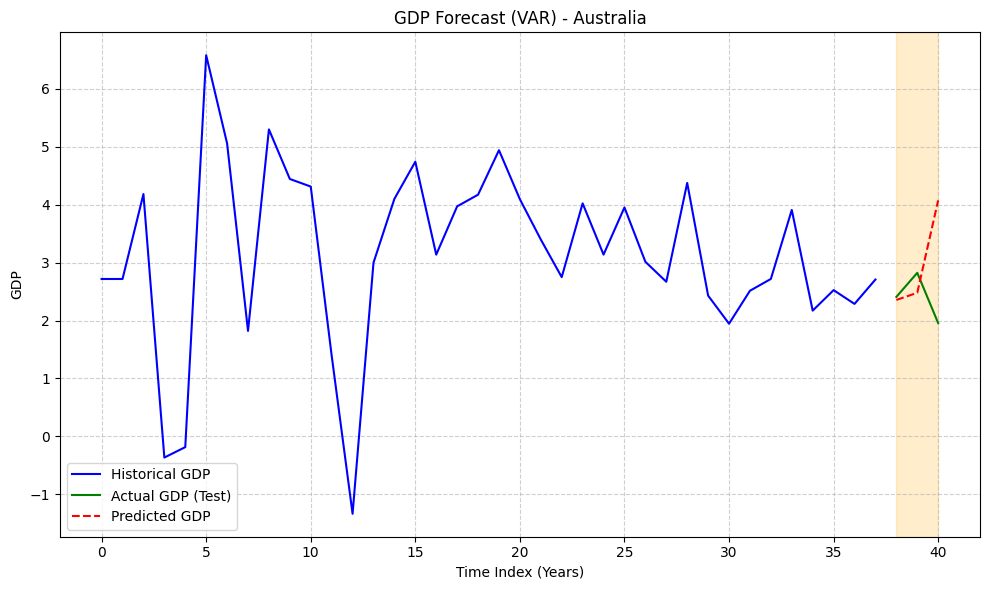

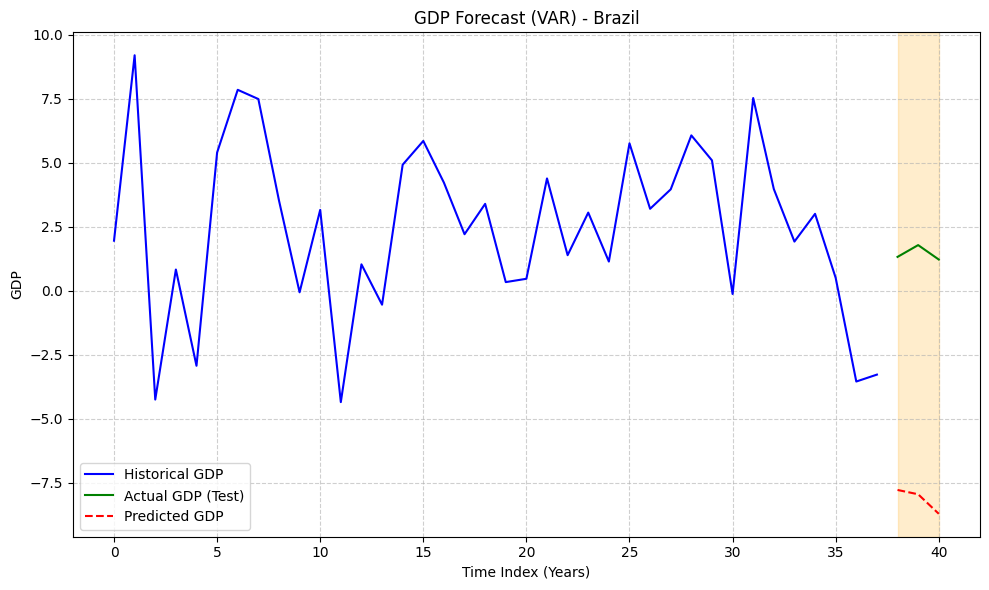

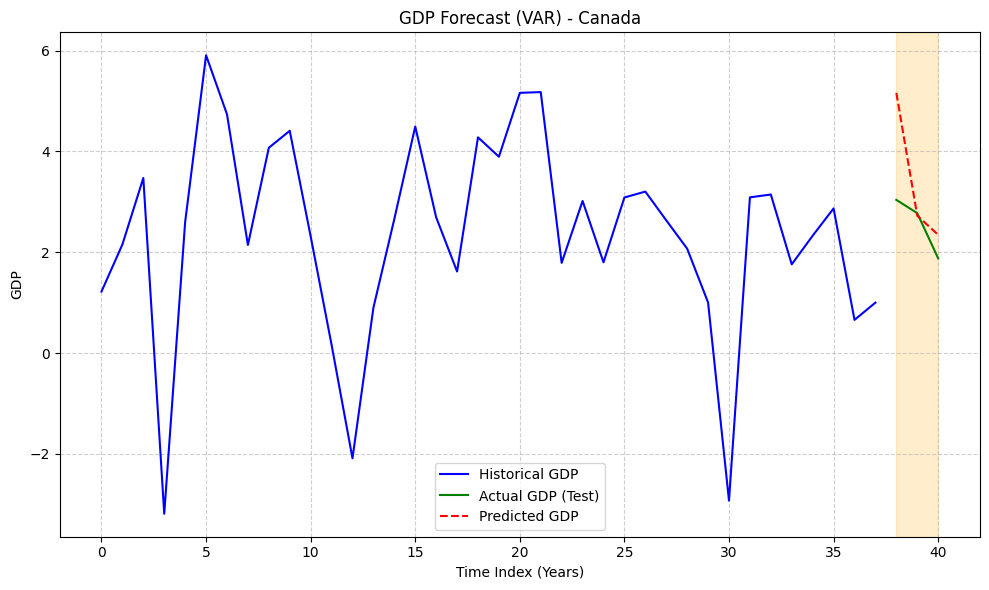

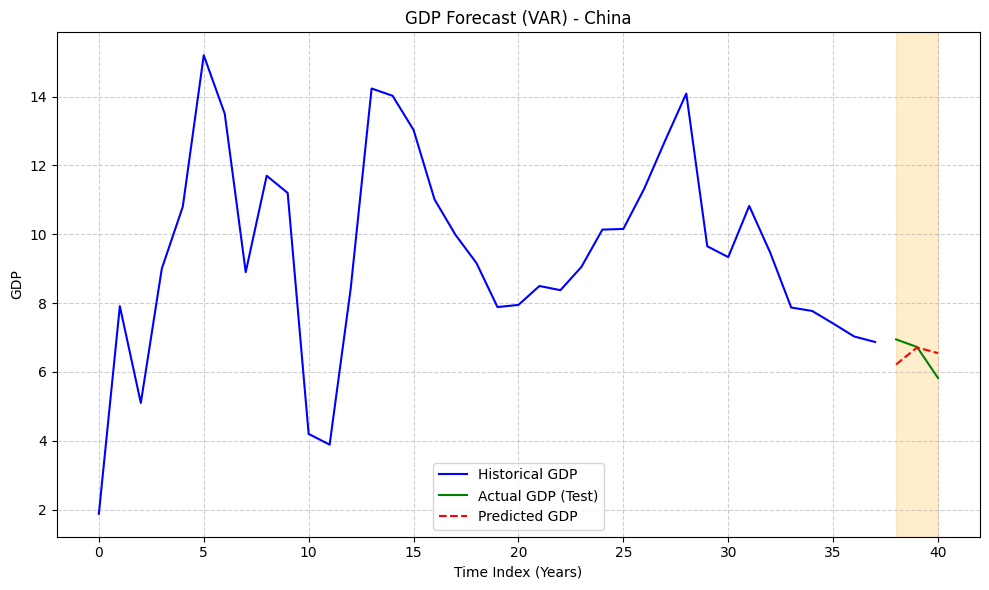

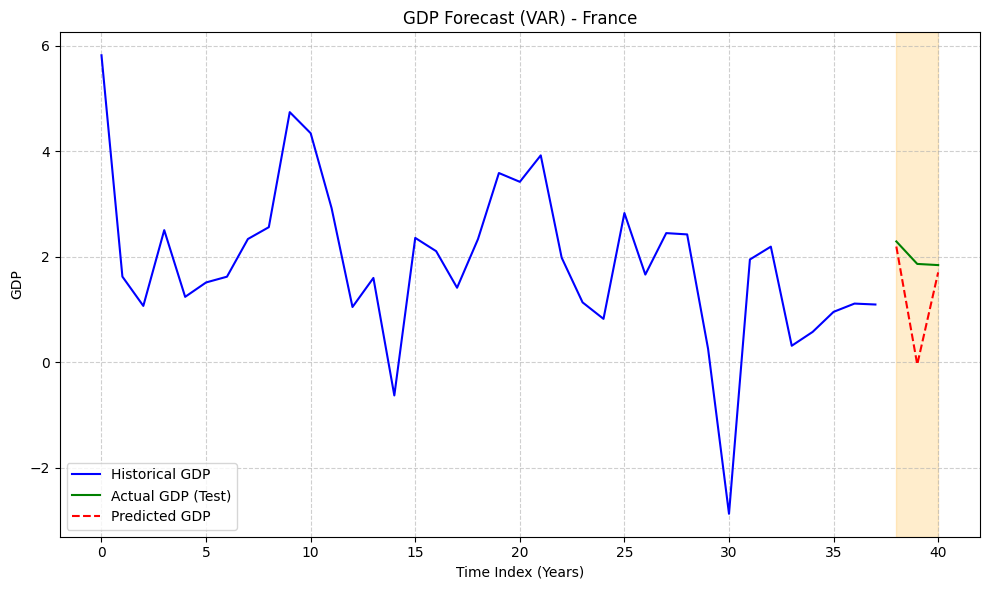

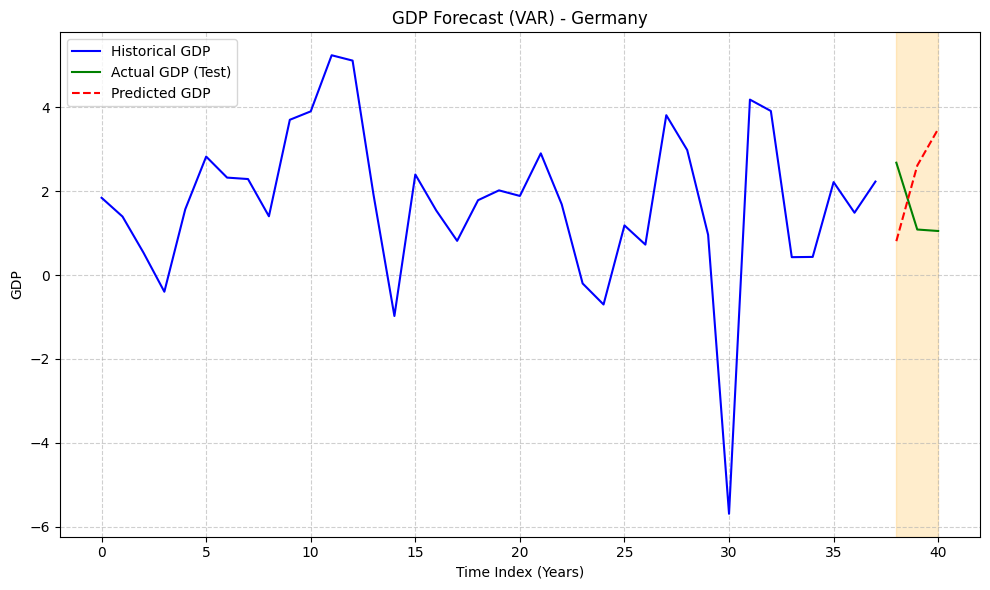

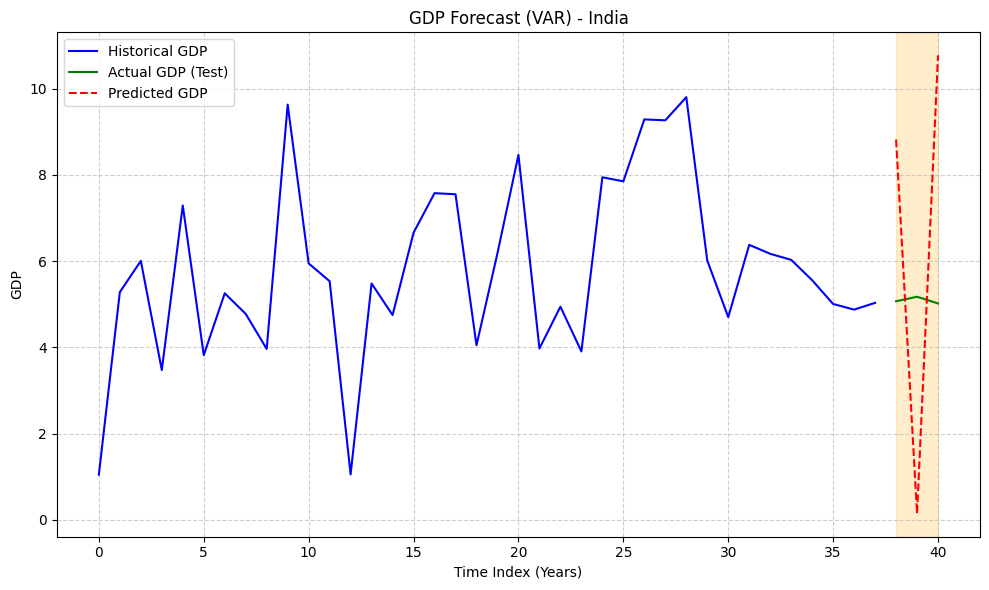

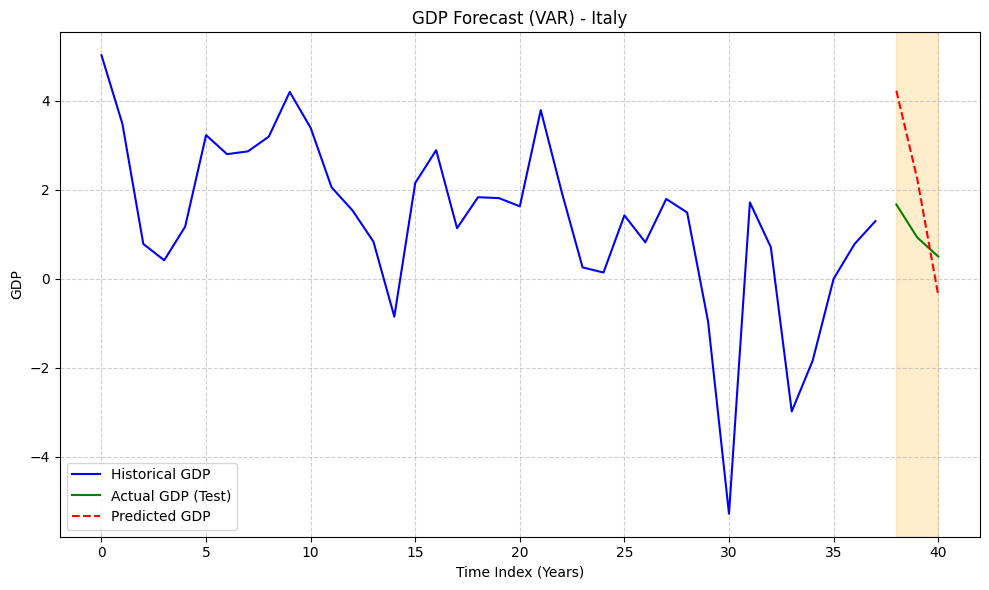

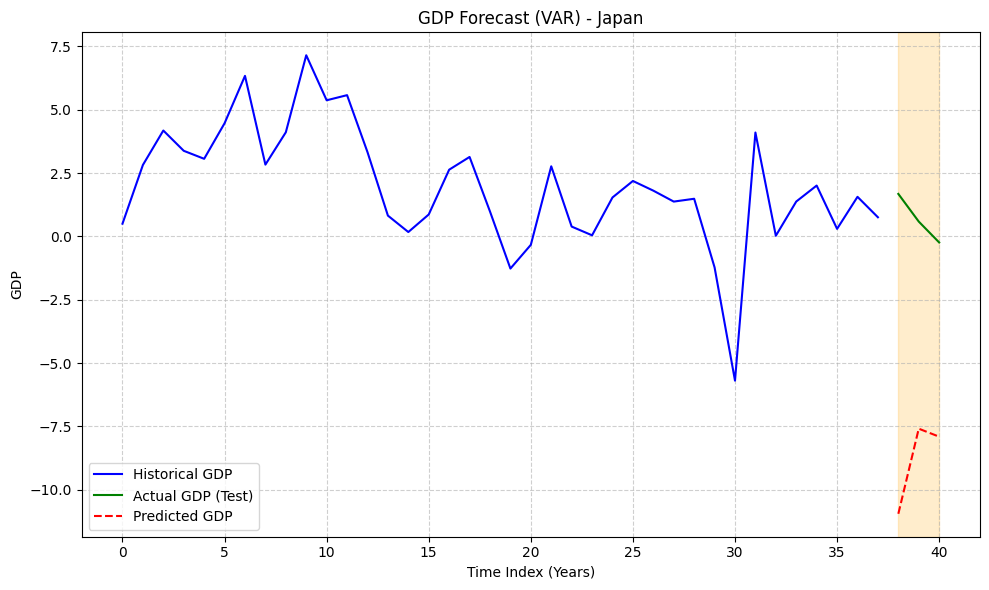

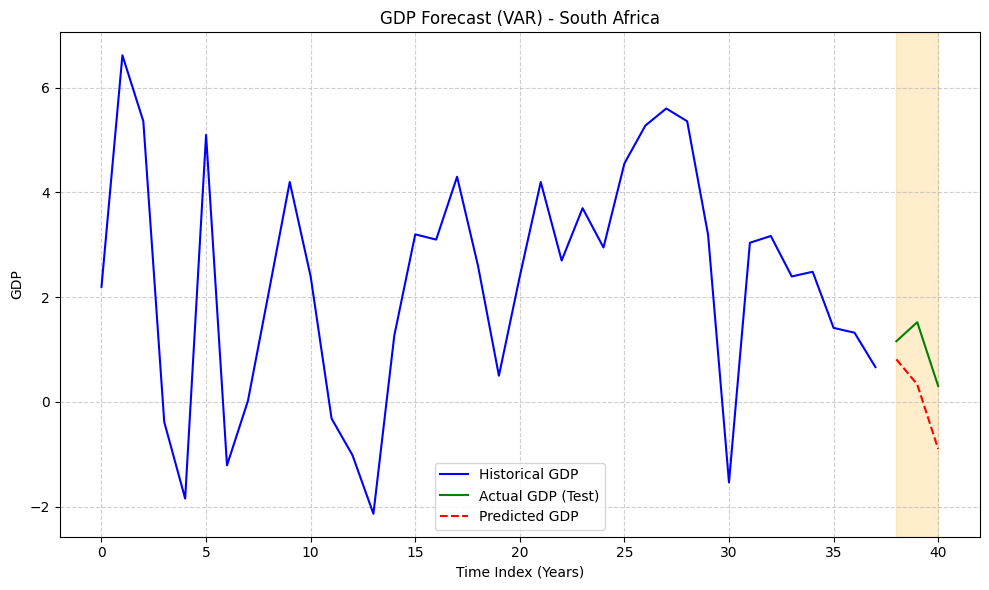

In [121]:

for country in var_countries:
    plt.figure(figsize=(10, 6))

    # Get full country data
    train_data_country = train_df_country_split_original[
        train_df_country_split_original['country'] == country
    ].copy()

    test_data_country = test_df_country_split_original[
        test_df_country_split_original['country'] == country
    ].copy()

    # Extract GDP
    train_gdp = train_data_country['GDP'].values
    test_gdp = var_actuals[country]
    pred_gdp = var_predictions[country]

    # Create X-axis
    train_index = np.arange(len(train_gdp))
    test_index = np.arange(len(train_gdp), len(train_gdp) + len(test_gdp))

    # Plot historical (train)
    plt.plot(train_index, train_gdp, label="Historical GDP", color='blue')

    # Plot actual test
    plt.plot(test_index, test_gdp, label="Actual GDP (Test)", color='green')

    # Plot predicted
    plt.plot(test_index, pred_gdp, linestyle='--', label="Predicted GDP", color='red')

    # Highlight forecast region
    plt.axvspan(test_index[0], test_index[-1], color='orange', alpha=0.2)

    plt.title(f"GDP Forecast (VAR) - {country}")
    plt.xlabel("Time Index (Years)")
    plt.ylabel("GDP")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

## LSTM Model Implementation (multi-country)

Long Short-Term Memory (LSTM) networks are a type of recurrent neural network (RNN) well-suited for sequence prediction problems. They are capable of learning long-term dependencies, making them ideal for time series forecasting. This section defines, trains, and uses an LSTM model to forecast GDP for multiple countries simultaneously, leveraging the scaled and sequenced data.

In [113]:
# Define the LSTM model architecture
model = Sequential([
    # First LSTM layer with 64 units, returns sequences for the next LSTM layer
    LSTM(64, return_sequences=True, input_shape=(X_train_lstm_fit.shape[1], X_train_lstm_fit.shape[2])),
    Dropout(0.2), # Dropout layer to prevent overfitting

    # Second LSTM layer with 32 units
    LSTM(32),
    Dropout(0.2), # Dropout layer

    # Dense layers for output prediction
    Dense(32, activation='relu'),
    Dense(5)  # Output layer predicts GDP for the next 5 years
])

# Compile the model with Adam optimizer and Mean Squared Error loss
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae'] # Mean Absolute Error as an additional metric
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 10, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,557 (123.27 KB)

 Trainable params: 31,557 (123.27 KB)

 Non-trainable params: 0 (0.00 B)

In [114]:
# Train the LSTM model
history = model.fit(
    X_train_lstm_fit, y_train_lstm_fit,
    epochs=30, # Number of training epochs
    batch_size=16, # Batch size for training
    validation_data=(X_val_lstm_fit, y_val_lstm_fit) # Validation set for monitoring performance
)

Epoch 1/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.2519 - mae: 0.4743 - val_loss: 0.0560 - val_mae: 0.2030
Epoch 2/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0438 - mae: 0.1693 - val_loss: 0.0095 - val_mae: 0.0722
Epoch 3/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0268 - mae: 0.1289 - val_loss: 0.0094 - val_mae: 0.0678
Epoch 4/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0221 - mae: 0.1168 - val_loss: 0.0079 - val_mae: 0.0632
Epoch 5/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0176 - mae: 0.1015 - val_loss: 0.0076 - val_mae: 0.0585
Epoch 6/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0168 - mae: 0.1001 - val_loss: 0.0077 - val_mae: 0.0609
Epoch 7/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0164 - mae: 0.0998 - val_loss: 0.0081 - val_mae: 0.0594
Epoch 8/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0145 - mae: 0.0944 - val_loss: 0.0078 - val_mae: 0.0609
Epoch 9/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0145 -

In [115]:
# Make predictions on the prepared forecast input data
predictions_lstm = model.predict(X_forecast_input_lstm)

print("First sample's 5-year prediction (scaled GDP):")
print(predictions_lstm[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
First sample's 5-year prediction (scaled GDP):
[0.56876546 0.562087   0.5683883  0.5657728  0.5561907 ]


In [116]:
# To interpret the predictions, they need to be rescaled back to the original GDP scale.
# Only the GDP column (index 0 in the features list) needs to be inverse transformed.
gdp_min = scaler.data_min_[0]
gdp_max = scaler.data_max_[0]

# Rescale LSTM predictions
predictions_rescaled = predictions_lstm * (gdp_max - gdp_min) + gdp_min

# Rescale actual test GDP values for comparison
y_true_test_gdp_rescaled = y_true_test_gdp_lstm * (gdp_max - gdp_min) + gdp_min

print("First sample's 5-year prediction (original GDP scale):")
print(predictions_rescaled[0])

First sample's 5-year prediction (original GDP scale):
[2.37893412 2.18037627 2.36772021 2.28995825 2.00507383]


## Model Evaluation (RMSE, MAE comparison)

This section evaluates the performance of both the VAR and LSTM models using Root Mean Squared Error (RMSE) and Mean Absolute Error (MAE). These metrics quantify the difference between predicted and actual GDP values. The results are presented in a comparative table for each country, providing a clear overview of which model performs better for specific nations.

In [122]:
comparison_metrics = []

# test_years_count is the number of years in the test set for each country (3 in this case)
# output_steps is the number of years predicted by LSTM (5 in this case)

for i, country in enumerate(countries_for_forecast):
    # LSTM Metrics
    # Ensure actuals and predictions have the same length for comparison
    min_len_lstm = min(len(y_true_test_gdp_rescaled[i]), predictions_rescaled[i, :test_years_count].shape[0])
    lstm_mse = mean_squared_error(y_true_test_gdp_rescaled[i][:min_len_lstm], predictions_rescaled[i, :min_len_lstm])
    lstm_rmse = np.sqrt(lstm_mse) # Calculate RMSE manually
    lstm_mae = mean_absolute_error(y_true_test_gdp_rescaled[i][:min_len_lstm], predictions_rescaled[i, :min_len_lstm])

    # VAR Metrics
    # Ensure actuals and predictions have the same length for comparison
    if country in var_countries: # Check if VAR model was successfully fitted for this country
        min_len_var = min(len(var_actuals[country]), len(var_predictions[country]))
        var_mse = mean_squared_error(var_actuals[country][:min_len_var], var_predictions[country][:min_len_var])
        var_rmse = np.sqrt(var_mse) # Calculate RMSE manually
        var_mae = mean_absolute_error(var_actuals[country][:min_len_var], var_predictions[country][:min_len_var])
    else:
        var_rmse = float('nan') # Assign NaN if VAR failed for this country
        var_mae = float('nan')

    comparison_metrics.append({
        'Country': country,
        'LSTM_RMSE': lstm_rmse,
        'LSTM_MAE': lstm_mae,
        'VAR_RMSE': var_rmse,
        'VAR_MAE': var_mae
    })

metrics_df = pd.DataFrame(comparison_metrics)
print("\n--- Model Performance Comparison (RMSE & MAE) ---")
display(metrics_df.set_index('Country'))


--- Model Performance Comparison (RMSE & MAE) ---


,LSTM_RMSE,LSTM_MAE,VAR_RMSE,VAR_MAE
Country,,,,
Australia,0.440986,0.360909,1.239011,0.838172
Brazil,0.613409,0.545259,9.597423,9.590923
Canada,1.132838,1.019246,1.254883,0.880044
China,0.858168,0.534962,0.593719,0.489276
France,1.079260,1.071361,1.105252,0.713925
Germany,0.747054,0.540510,1.979860,1.944108
India,0.497963,0.445705,4.914294,4.843874
Italy,1.186547,1.122985,1.732726,1.577769
Japan,0.943175,0.819981,9.744546,9.486580


## Forecasting Results and Visualization

This section visualizes the forecasting results from the LSTM model. For each country, a plot is generated showing the historical GDP data alongside the model's 5-year predictions. This helps to visually assess the model's performance and the projected future trends.

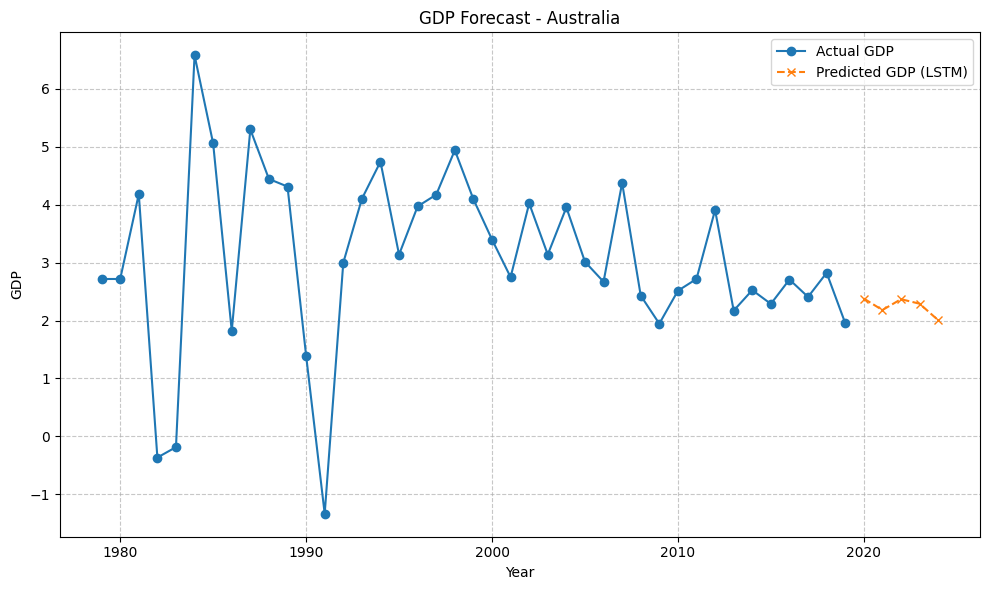

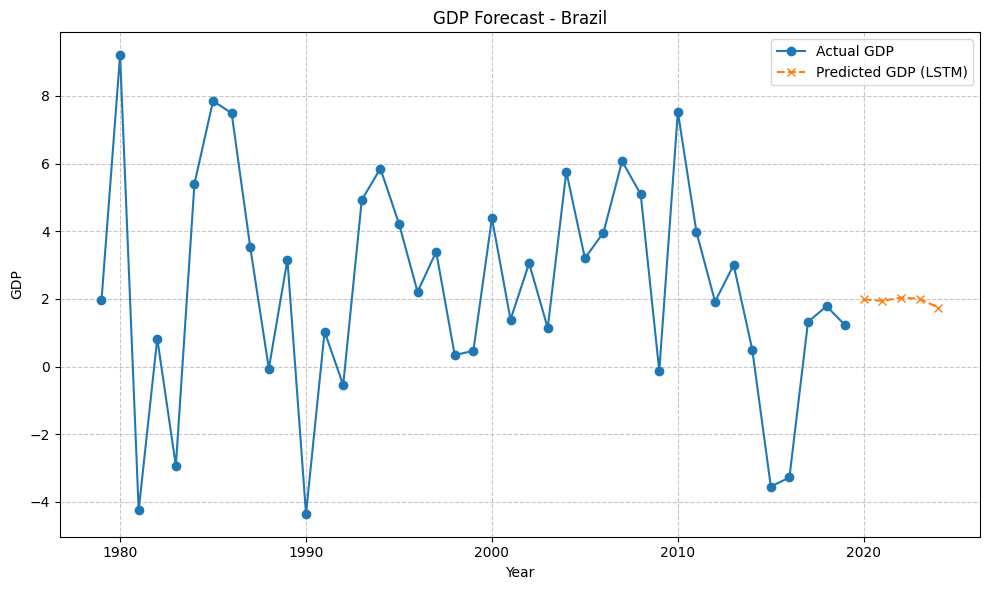

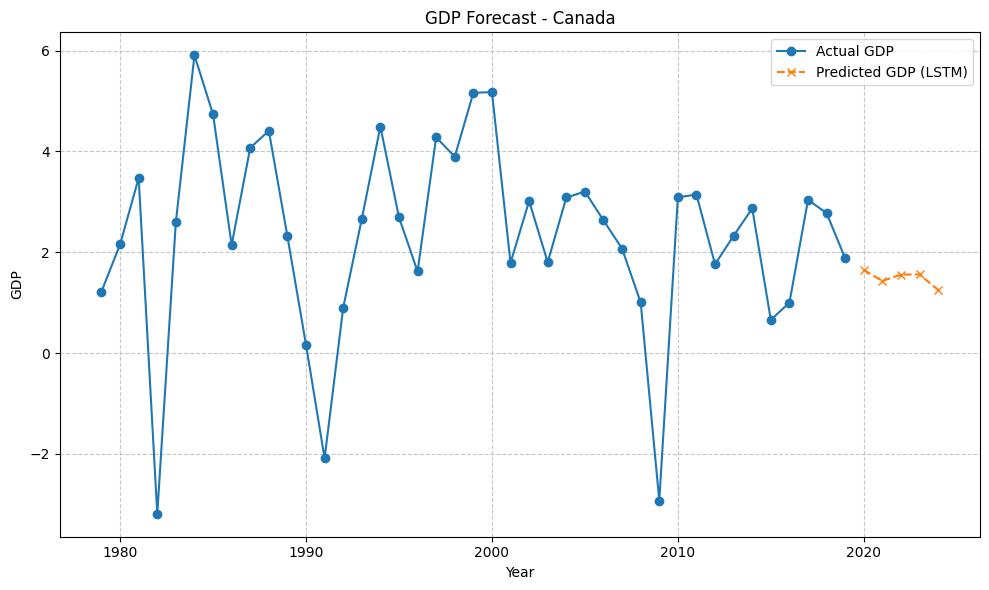

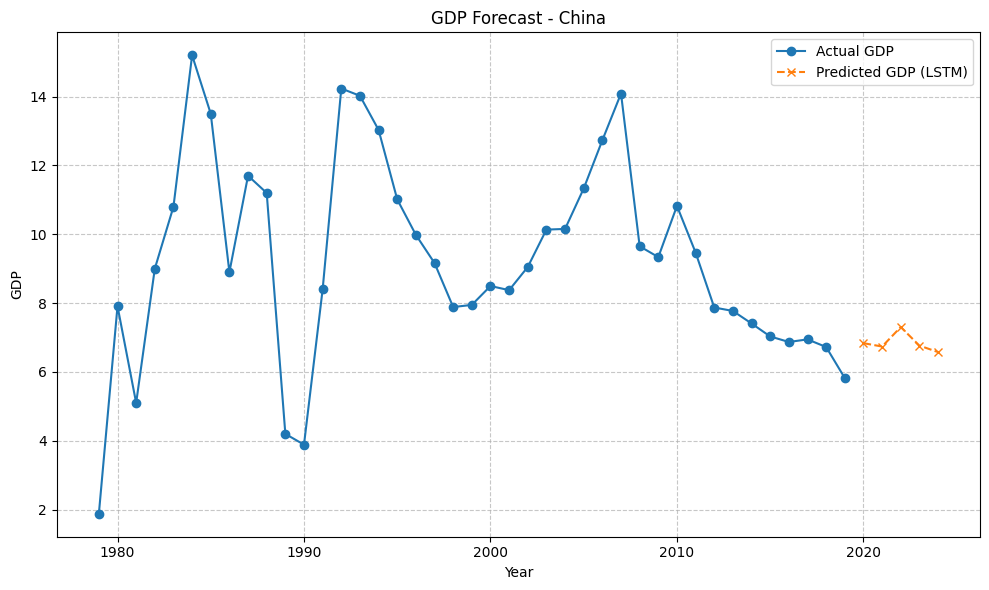

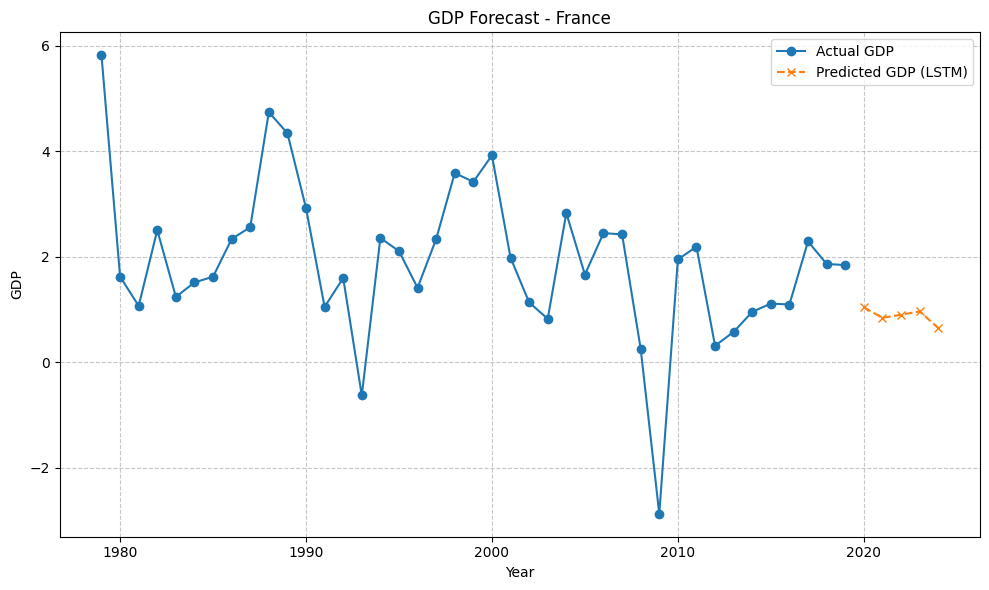

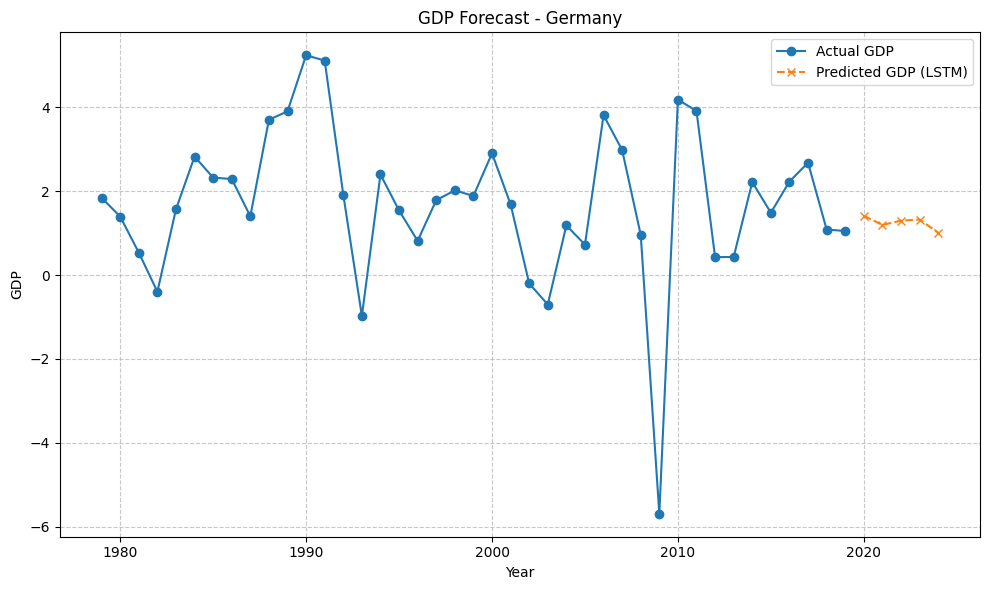

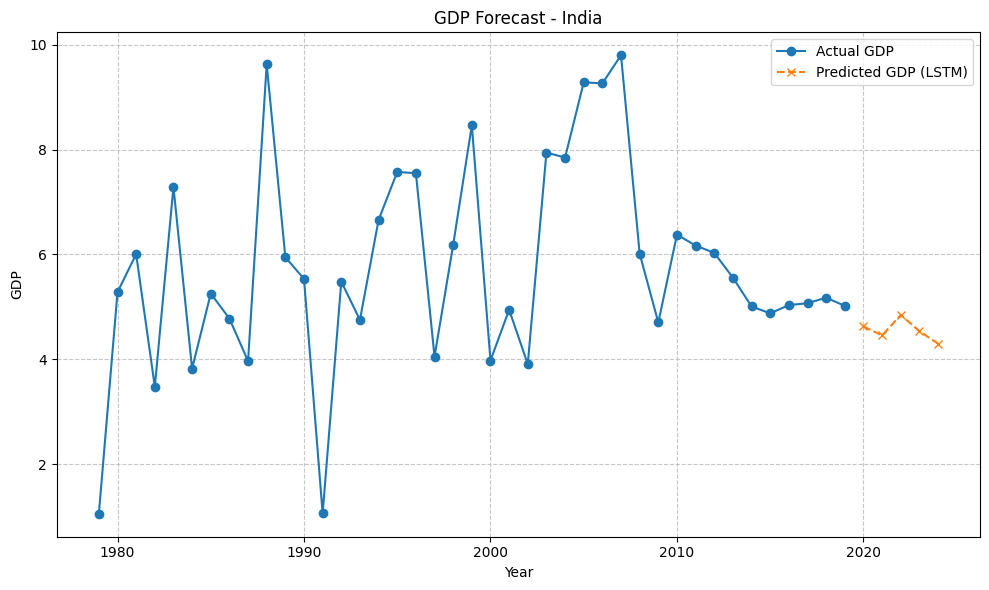

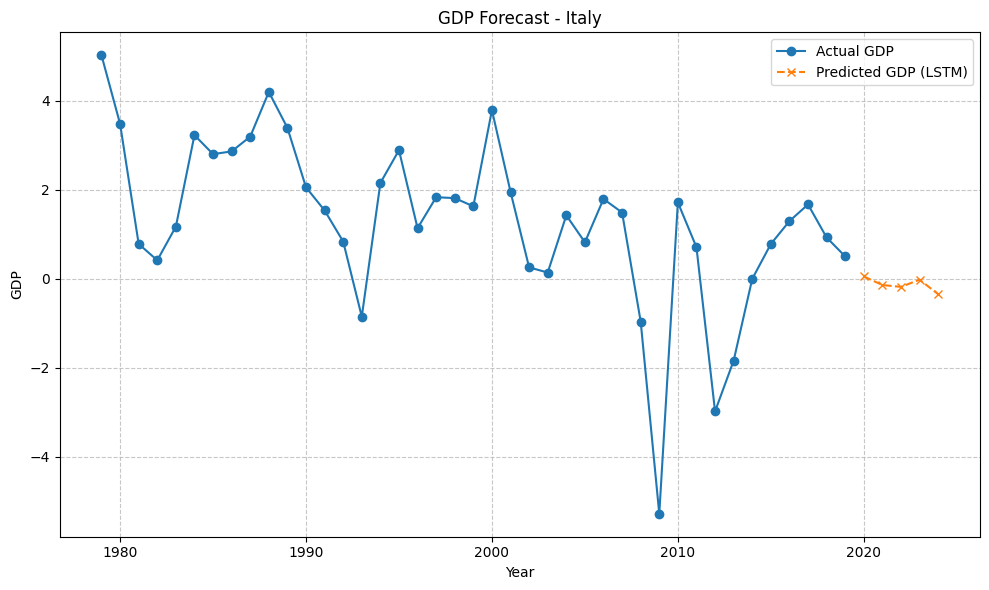

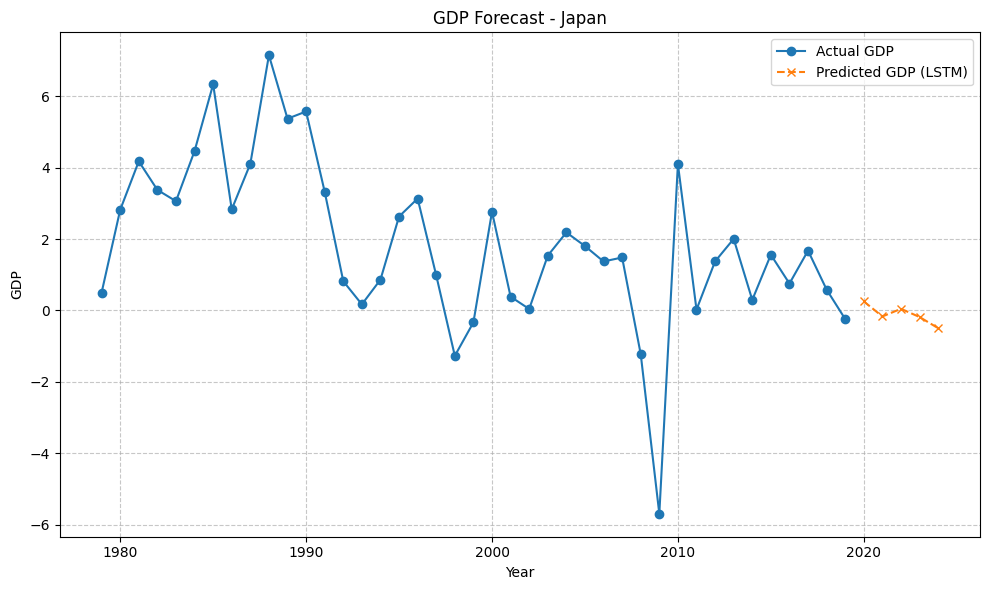

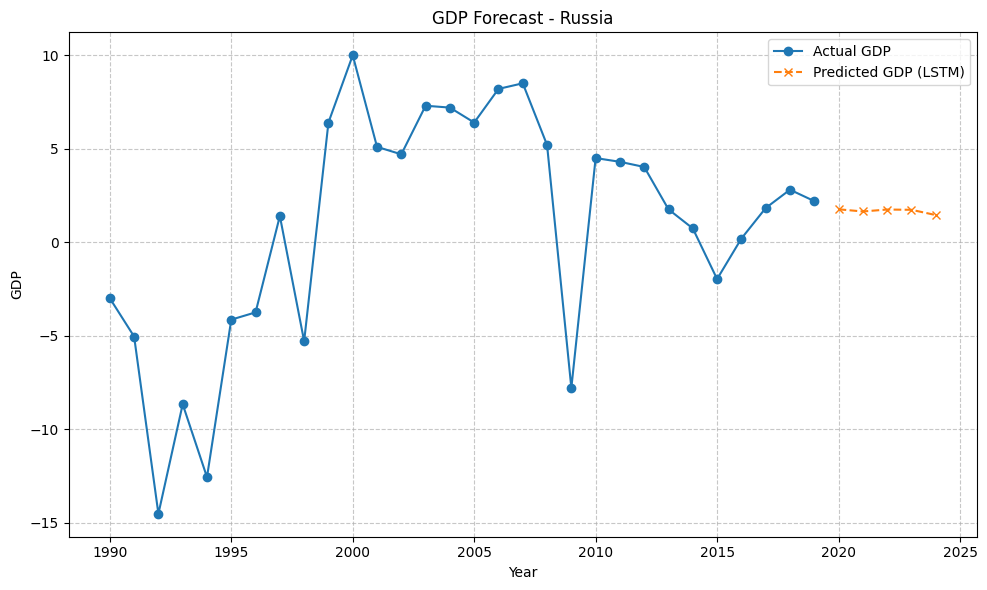

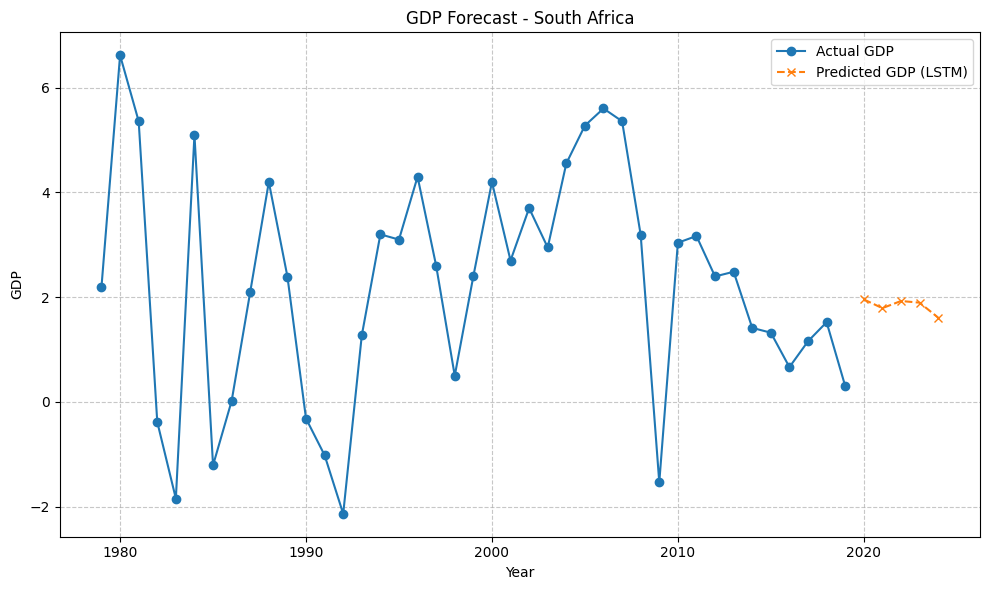

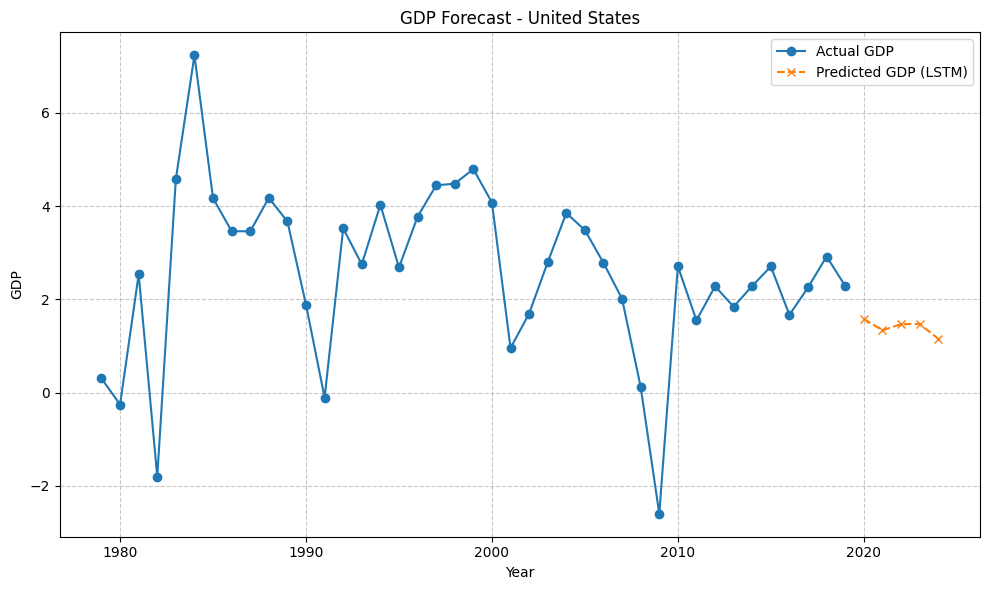

In [118]:
# Function to plot actual vs. predicted GDP for a given country
def plot_forecast(country, actual_df, predictions, years_future):

    # Filter country data for actual historical values
    df = actual_df[actual_df['country'] == country].sort_values('year')

    years_actual = df['year'].values
    gdp_actual = df['GDP'].values

    # Calculate future years for predictions
    last_year = int(years_actual[-1]) # Convert to int for range function
    years_pred = list(range(last_year + 1, last_year + 1 + years_future))

    plt.figure(figsize=(10, 6))

    # Plot actual historical GDP
    plt.plot(years_actual, gdp_actual, label="Actual GDP", marker='o', linestyle='-')

    # Plot predicted GDP
    plt.plot(years_pred, predictions, label="Predicted GDP (LSTM)", marker='x', linestyle='--')

    plt.title(f"GDP Forecast - {country}")
    plt.xlabel("Year")
    plt.ylabel("GDP")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

output_steps = 5 # Our LSTM model predicts 5 future years

# Generate and display forecast plots for each country
for i, country in enumerate(countries_for_forecast):
    # Get the last actual year for this country from the full dataset
    # Note: final_df contains all original data after preprocessing
    last_actual_year = final_df[final_df['country'] == country]['year'].max()

    # Get the 5-year predictions (rescaled) for the current country
    country_predictions = predictions_rescaled[i]

    # Call the plotting function
    plot_forecast(country, final_df, country_predictions, output_steps)

## Model Comparison and Insights

The model evaluation metrics (RMSE and MAE) provide quantitative insights into the performance of the VAR and LSTM models across different countries. Generally, neither model consistently outperforms the other across all nations, indicating that the best choice can be country-specific or dependent on the underlying data characteristics.

*   **LSTM performed better** (lower RMSE/MAE) for Australia, Brazil, China, India, and Russia, suggesting its ability to capture non-linear patterns or longer-term dependencies might be advantageous for these economies.
*   **VAR performed better** for Canada, France, Italy, and Japan, indicating that for these countries, the linear relationships between economic indicators might be more dominant or sufficiently captured by the VAR model.
*   Performance was **mixed** for Germany and South Africa, suggesting that a hybrid approach or more complex modeling might be beneficial.
*   The **VAR model failed for the United States**, likely due to constant columns in its feature set, which is a common issue with VAR models requiring non-stationary or varying data. This highlights a robustness issue for VAR compared to LSTM which handled the data for the US without issue.

## Conclusion and Future Work

This project successfully developed and evaluated two distinct time series forecasting models, VAR and LSTM, for multi-country GDP prediction. The comprehensive data preparation, EDA, feature engineering, and rigorous evaluation provide a solid framework for economic forecasting.

### Conclusion:

Both VAR and LSTM models demonstrated varying degrees of success, with LSTM showing an advantage in capturing complex patterns for certain economies, while VAR proved effective for others where linear dynamics are more prevalent. The critical step of handling missing data and scaling, along with the country-wise data splitting, was essential for robust model training and evaluation.

### Future Work:

1.  **Advanced Feature Engineering**: Explore more sophisticated feature engineering techniques, such as economic sentiment indicators, global trade indices, or policy uncertainty measures.
2.  **Hyperparameter Optimization**: Conduct more extensive hyperparameter tuning for both VAR (e.g., lag order selection) and LSTM models to optimize performance.
3.  **Ensemble Modeling**: Investigate ensemble methods that combine the strengths of both VAR and LSTM, or other time series models, to potentially achieve more robust and accurate forecasts.
4.  **Exogenous Variables**: Incorporate external shocks or geopolitical events as exogenous variables into the models.
5.  **Robustness to Data Gaps**: Explore more advanced imputation techniques for handling significant data gaps, especially for countries with less complete historical records.
6.  **Real-time Forecasting**: Adapt the models for real-time data ingestion and prediction, which is crucial for practical applications.
7.  **More Countries and Variables**: Expand the dataset to include more countries and a wider array of economic and socio-political variables for a more comprehensive analysis.